The first part was a test to identify hotspots in a somewhat simpler way for the presentation. The second part was a test for a more advanced hotspot identification method: Local Moran's I

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from libpysal.weights import Queen
import glob
import os
from esda.moran import Moran_Local
from rapidfuzz import process
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
df_street_crimes = pd.read_csv("data_correlation_test/combined_data.csv")
print("Street crime data has been read")

Street crime data has been read


Information about police forces:
https://www.police.uk/pu/contact-us/uk-police-forces/ (39 in England, 1 Northern IReland (Police Service of Northern Ireland), 1 scotland(Police scotland), 4 Wales(Dyfed-Powys Police, North Wales Police, South Wales Police, Gwent))
4 national special forces: British Transport Police, civil nuclear, and ministery of defence. 
<br>

The mission of the British Transport Police is to protect the rail community against crime. This is different from local police forces, which focus on keeping local communities safe. https://www.btp.police.uk/police-forces/british-transport-police/areas/about-us/about-us/vision-mission-values/
We should remove the British Transport Police since it is a national force with a different goal.
<br>

Scotland is not in the database and we removed northern ireland since the LSOA data is missing for that, so only data of England and Wales.
There is one force missing in this dataset: Greater Manchester Police
<br>

Cleaning the data:
- remove the column Context, since has no information in it
- Since the goal is to forecast the number of crimes and their types per LSOA, we remove rows where LSOA information is missing .
- Remove the British Transport Police force, since it is a national special force with a different goal

In [3]:
if "Context" in df_street_crimes.columns:
    df_street_crimes = df_street_crimes.drop(columns=["Context"])
    
df_street_crimes = df_street_crimes.dropna(subset=["LSOA name", "LSOA code"])
df_street_crimes = df_street_crimes[df_street_crimes["Reported by"] != "British Transport Police"]
df_street_crimes.info()

<class 'pandas.DataFrame'>
Index: 17114545 entries, 0 to 17880939
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Crime ID               str    
 1   Month                  str    
 2   Reported by            str    
 3   Falls within           str    
 4   Longitude              float64
 5   Latitude               float64
 6   Location               str    
 7   LSOA code              str    
 8   LSOA name              str    
 9   Crime type             str    
 10  Last outcome category  str    
dtypes: float64(2), str(9)
memory usage: 4.7 GB


In [4]:
df_london = df_street_crimes[
    df_street_crimes["Reported by"] == "Metropolitan Police Service"
].copy()

In [5]:
base_path = "data_correlation_test/LSOA_location_info"
shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)

lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
lsoa_locations = gpd.GeoDataFrame(
    pd.concat(lsoa_gdfs, ignore_index=True),
    crs=lsoa_gdfs[0].crs
)
lsoa_locations.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35672 entries, 0 to 35671
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   LSOA21CD   35672 non-null  str     
 1   LSOA21NM   35672 non-null  str     
 2   LSOA21NMW  1917 non-null   str     
 3   BNG_E      35672 non-null  int64   
 4   BNG_N      35672 non-null  int64   
 5   LAT        35672 non-null  float64 
 6   LONG       35672 non-null  float64 
 7   GlobalID   35672 non-null  str     
 8   geometry   35672 non-null  geometry
dtypes: float64(2), geometry(1), int64(2), str(4)
memory usage: 4.6 MB


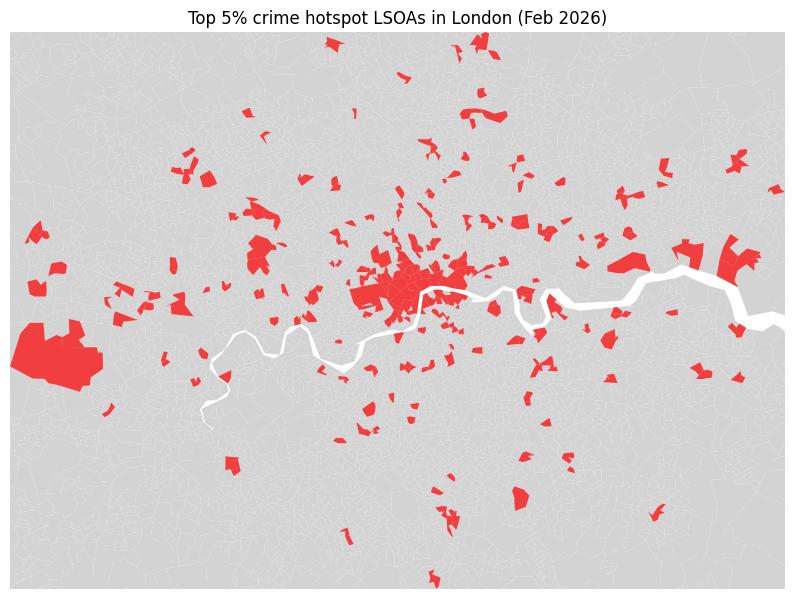

In [6]:
df_feb_2026 = df_london[
    df_london["Month"] == "2026-02"
].copy()

df_crime_london_feb = (
    df_feb_2026.groupby("LSOA code")
    .size()
    .reset_index(name="crime_count")
)

threshold = df_crime_london_feb["crime_count"].quantile(0.95)

hotspots = df_crime_london_feb[
    df_crime_london_feb["crime_count"] >= threshold
].copy()

hotspot_map = lsoa_locations.merge(
    hotspots,
    left_on="LSOA21CD",
    right_on="LSOA code",
    how="inner"
)

ax = lsoa_locations.plot(
    color="lightgrey",
    figsize=(10, 10)
)

hotspot_map.plot(
    ax=ax,
    color="red",
    alpha = 0.7,
    legend=False
)

# zoom to London
xmin, ymin, xmax, ymax = hotspot_map.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title("Top 5% crime hotspot LSOAs in London (Feb 2026)")
ax.set_axis_off()

# Advanced clustering: Local Moran's I

dataset used for the force boundaries: https://www.gov.uk/government/statistics/police-workforce-open-data-tables 
<br>
named:Police workforce, England and Wales, 31 March 2025: workforce open data tables

In [7]:
# Add force boundaries
kml_folder = "data_correlation_test/force kmls"
kml_files = glob.glob(os.path.join(kml_folder, "**/*.kml"), recursive=True)

force_gdfs = []
for file in kml_files:
    gdf = gpd.read_file(file, driver="KML")
    gdf["force"] = os.path.basename(file).replace(".kml", "")
    force_gdfs.append(gdf)

forces = gpd.GeoDataFrame(pd.concat(force_gdfs, ignore_index=True))
forces = forces.to_crs(lsoa_locations.crs)
lsoa_locations = lsoa_locations.to_crs(forces.crs)
forces["geometry"] = forces["geometry"].buffer(0)

In [8]:
crime_monthly = (
    df_street_crimes
    .groupby(["Reported by", "LSOA code", "Month"])
    .size()
    .reset_index(name="crimes")
)

forces_reported_by = crime_monthly["Reported by"].unique()
kml_forces = list(forces["force"].unique())

# remove northern ireland and greater-manchester from the kml since not in the df_Street_crimes database
kml_forces.remove("northern-ireland")
kml_forces.remove("greater-manchester")

# Mapping the reported by force names to kml names, since they are not the same
map_force_names = {}

for cf in forces_reported_by:
    match = process.extractOne(cf, kml_forces)
    map_force_names[cf] = match[0]
    
# To manually check if mapping is correct
for k, v in list(map_force_names.items())[:]:
    print(k, "→", v)

crime_monthly["force_kml"] = crime_monthly["Reported by"].map(map_force_names)

# wrongly mapped:
# North Yorkshire Police → cheshire, correction: North Yorkshire Police → north-yorkshire
# Nottinghamshire Police → hampshire, correction: Nottinghamshire Police → nottinghamshire
# South Yorkshire Police → cheshire, correction: South Yorkshire Police → south-yorkshire

map_force_names["North Yorkshire Police"] = "north-yorkshire"
map_force_names["Nottinghamshire Police"] = "nottinghamshire"
map_force_names["South Yorkshire Police"] = "south-yorkshire"

lsoa_locations = lsoa_locations.rename(columns={
    "LSOA21CD": "LSOA code"
})

def get_monthly_hotspots_force(
    crime_monthly: pd.DataFrame,
    lsoa_gdf: gpd.GeoDataFrame,
    month,
    police_force,
    lsoa_col="LSOA code",
    month_col="Month",
    value_col="crimes",
    significance=0.05
):
    """
    Computes hotspots using Local Moran's I for a selected police force (kml name) and month.
    Returns: a geopanda geodataframe with the LSOA geometries, reported by, crime count, month, name of kml force file, 
    Local Moran's I values, p-values, moran quadrants, classification type
    
    """

    # filter data to keep chosen month and police force
    df_filtered = crime_monthly[
        (crime_monthly[month_col] == month) &
        (crime_monthly["force_kml"] == police_force)
    ].copy()

    # get force geometry and make one shape/boundary
    force_geom = forces[forces["force"] == police_force].copy()
    force_geom = force_geom[force_geom.geometry.notnull()].copy()

    if len(force_geom) == 0:
        raise ValueError(f"No valid geometry for {police_force}")

    force_union = force_geom.geometry.unary_union

    # get only lsoa's that are in in the force boundary 
    lsoa_force = lsoa_gdf[
    lsoa_gdf.geometry.intersects(force_union.buffer(0))].copy()

    gdf = lsoa_force.merge(df_filtered, on=lsoa_col, how="left")
    gdf[value_col] = gdf[value_col].fillna(0)

    # spatial weights
    w = Queen.from_dataframe(gdf)
    w.transform = "r"

    # Local Morans I
    lisa = Moran_Local(gdf[value_col], w)

    gdf["Is"] = lisa.Is
    gdf["p_sim"] = lisa.p_sim
    gdf["quadrant"] = lisa.q

    sig = lisa.p_sim < significance

    cluster_map = {
        0: "Non-significant",
        1: "High-High (Hotspot)",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    clusters = lisa.q.copy()
    clusters[~sig] = 0

    # Create column with cluster label
    gdf["cluster_classification"] = pd.Series(
        clusters,
        index=gdf.index
    ).map(cluster_map)

    met_lsoa_count = lsoa_gdf.geometry.intersects(forces[forces["force"] == "metropolitan"].geometry.unary_union.buffer(0)).sum()
    print(f"number of LSOA's in metropolitan force: {met_lsoa_count}")

    return gdf



Avon and Somerset Constabulary → avon-and-somerset
Bedfordshire Police → bedfordshire
Cambridgeshire Constabulary → cambridgeshire
Cheshire Constabulary → cheshire
City of London Police → city-of-london
Cleveland Police → cleveland
Cumbria Constabulary → cumbria
Derbyshire Constabulary → derbyshire
Devon & Cornwall Police → devon-and-cornwall
Dorset Police → dorset
Durham Constabulary → durham
Dyfed-Powys Police → dyfed-powys
Essex Police → essex
Gloucestershire Constabulary → gloucestershire
Gwent Police → gwent
Hampshire Constabulary → hampshire
Hertfordshire Constabulary → hertfordshire
Humberside Police → humberside
Kent Police → kent
Lancashire Constabulary → lancashire
Leicestershire Police → leicestershire
Lincolnshire Police → lincolnshire
Merseyside Police → merseyside
Metropolitan Police Service → metropolitan
Norfolk Constabulary → norfolk
North Wales Police → north-wales
North Yorkshire Police → cheshire
Northamptonshire Police → northamptonshire
Northumbria Police → northu

In [9]:
hotspots = get_monthly_hotspots_force(
    crime_monthly=crime_monthly,
    lsoa_gdf=lsoa_locations,
    month="2025-01",
    police_force="metropolitan"
)
hotspots.head()

hotspot_count = (hotspots["cluster_classification"] == "High-High (Hotspot)").sum()
print(f"  Found {hotspot_count} hotspots for metropolitan")

C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\3549740465.py:71: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\3549740465.py:81: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\3549740465.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  met_lsoa_count = lsoa_gdf.geometry.intersects(forces[forces["force"] == "metropolitan"].geometry.unary_union.buffer(0)).sum()


number of LSOA's in metropolitan force: 5121
  Found 291 hotspots for metropolitan


In [12]:
crime_3y = (
    df_street_crimes
    .groupby(["Reported by", "LSOA code"])
    .size()
    .reset_index(name="crimes")
)

crime_3y["force_kml"] = crime_3y["Reported by"].map(map_force_names)

def get_hotspots_3y_force(
    crime_3y: pd.DataFrame,
    lsoa_gdf: gpd.GeoDataFrame,
    police_force,
    lsoa_col="LSOA code",
    value_col="crimes",
    significance=0.05
):

    df_filtered = crime_3y[
        crime_3y["force_kml"] == police_force
    ].copy()

    force_geom = forces[forces["force"] == police_force].copy()
    force_geom = force_geom[force_geom.geometry.notnull()].copy()

    if len(force_geom) == 0:
        raise ValueError(f"No valid geometry for {police_force}")

    force_union = force_geom.geometry.unary_union

    lsoa_force = lsoa_gdf[
        lsoa_gdf.geometry.intersects(force_union.buffer(0))
    ].copy()

    gdf = lsoa_force.merge(df_filtered, on=lsoa_col, how="left")
    gdf[value_col] = gdf[value_col].fillna(0)

    w = Queen.from_dataframe(gdf)
    w.transform = "r"

    lisa = Moran_Local(gdf[value_col], w)

    gdf["Is"] = lisa.Is
    gdf["p_sim"] = lisa.p_sim
    gdf["quadrant"] = lisa.q

    sig = lisa.p_sim < significance

    cluster_map = {
        0: "Non-significant",
        1: "High-High (Hotspot)",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    clusters = lisa.q.copy()
    clusters[~sig] = 0

    gdf["cluster_classification"] = pd.Series(
        clusters,
        index=gdf.index
    ).map(cluster_map)

    return gdf

def hotspot_dict(gdf):
    hotspot_dict = {}

    for force in crime_3y["force_kml"].dropna().unique():

        hotspots = get_hotspots_3y_force(
            crime_3y=crime_3y,
            lsoa_gdf=lsoa_locations,
            police_force=force
        )

        hotspot_dict[force] = hotspots.loc[
            hotspots["cluster_classification"] == "High-High (Hotspot)",
            "LSOA code"
        ].dropna().unique().tolist()

    return hotspot_dict


import json

output_path = "hotspot_dict_3y.json"
result = hotspot_dict(lsoa_locations)

with open(output_path, "w") as f:
    json.dump(result, f, indent=4)

print(f"Saved to {output_path}")


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykern

('WARNING: ', 11, ' is an island (no neighbors)')


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykern

('WARNING: ', 553, ' is an island (no neighbors)')


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykern

Saved to hotspot_dict_3y.json


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykern

('WARNING: ', 11, ' is an island (no neighbors)')


C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykern

('WARNING: ', 553, ' is an island (no neighbors)')


c:\Users\20243092\AppData\Local\Programs\Python\Python311\Lib\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  force_union = force_geom.geometry.unary_union
C:\Users\20243092\AppData\Local\Temp\ipykernel_24280\2371288510.py:38: FutureWarning: `use_index` de

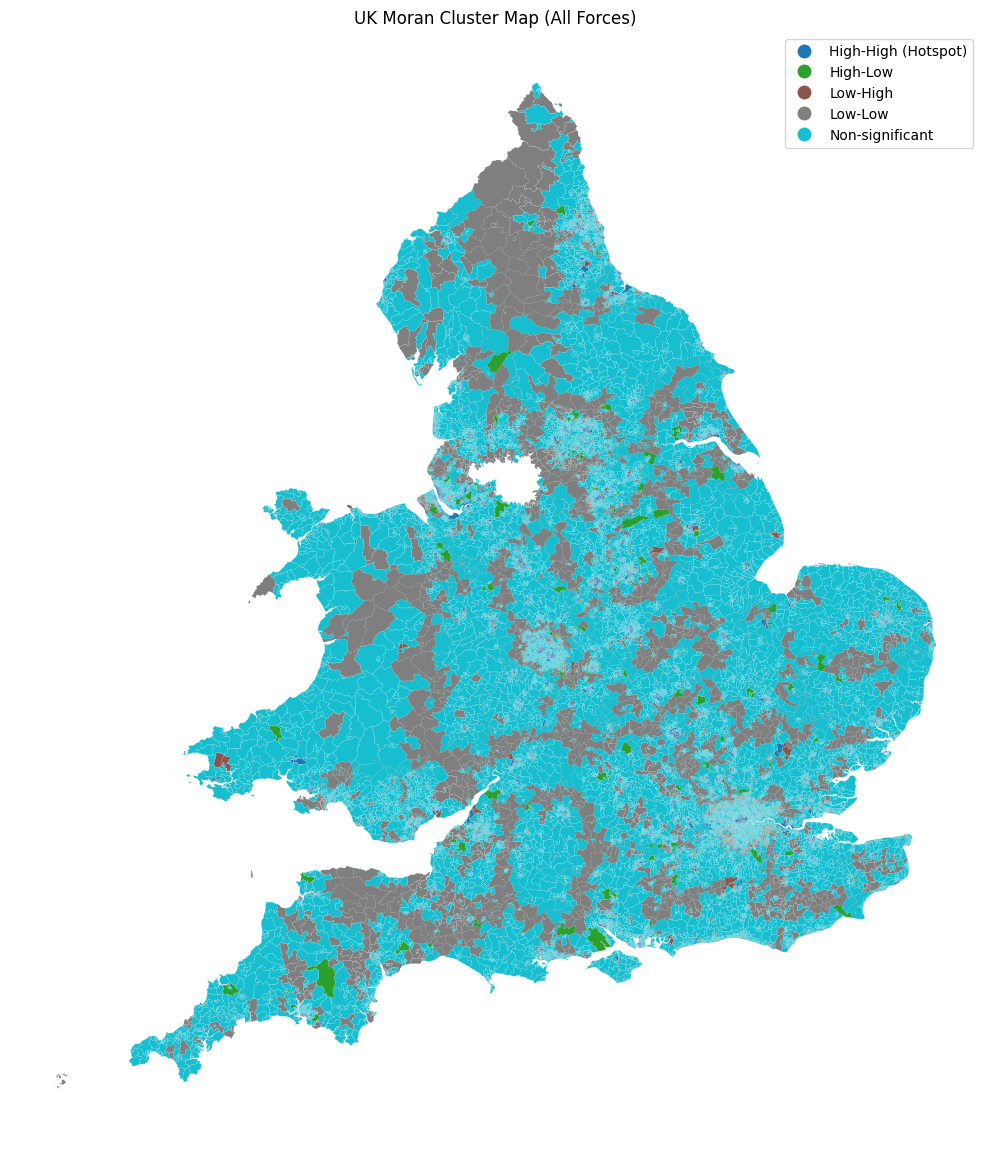

In [13]:
all_hotspots = []

for force in crime_3y["force_kml"].dropna().unique():
    gdf = get_hotspots_3y_force(
        crime_3y=crime_3y,
        lsoa_gdf=lsoa_locations,
        police_force=force
    )

    gdf["force_kml"] = force
    all_hotspots.append(gdf)

uk_hotspots = gpd.GeoDataFrame(pd.concat(all_hotspots, ignore_index=True))


def plot_moran_clusters(
    hotspots,
    column="cluster_classification",
    title="UK Moran Cluster Map (All Forces)",
    cmap="tab10",
    figsize=(10, 14)
):
    fig, ax = plt.subplots(figsize=figsize)

    hotspots.plot(
        column=column,
        categorical=True,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.05,
        legend=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_moran_clusters(
    hotspots,
    column="cluster_classification",
    title="UK Moran Cluster Map (All Forces)",
    cmap="tab10",
    figsize=(10, 14)
):
    fig, ax = plt.subplots(figsize=figsize)

    hotspots.plot(
        column=column,
        categorical=True,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.05,
        legend=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    plt.close()

plot_moran_clusters(uk_hotspots)

In [14]:
def plot_moran_clusters(
    hotspots,
    column="cluster_classification",
    title="Moran Cluster Map",
    cmap="tab10",
    figsize=(8, 8)
):
    fig, ax = plt.subplots(figsize=figsize)

    hotspots.plot(
        column=column,
        categorical=True,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.1,
        legend=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    plt.close()

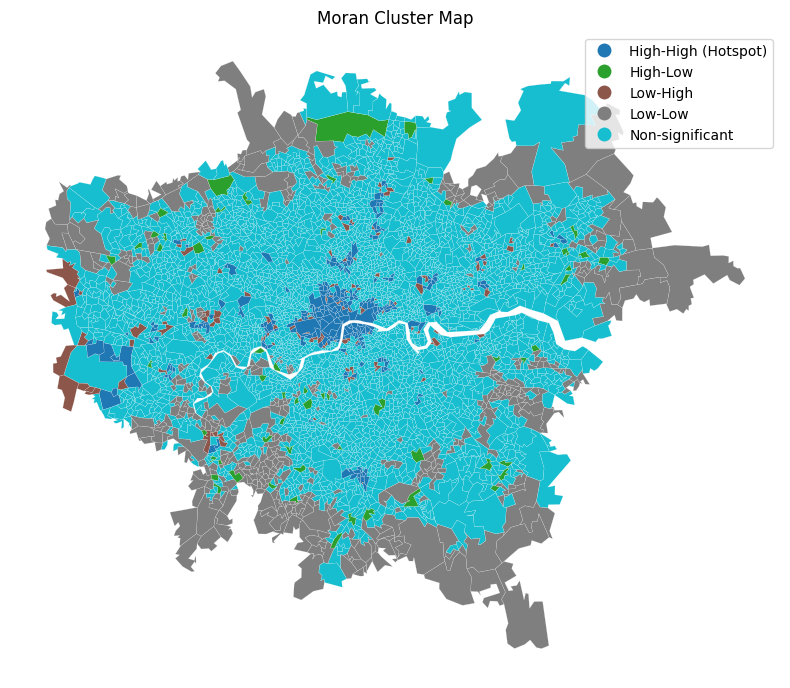

In [15]:
plot_moran_clusters(hotspots)

In [16]:
force_dropdown = widgets.Dropdown(
    options=sorted(crime_monthly["force_kml"].unique()),
    description="Force:"
)

month_dropdown = widgets.Dropdown(
    options=sorted(crime_monthly["Month"].unique()),
    description="Month:"
)

button = widgets.Button(description="ok")
output = widgets.Output()

def run_analysis(_):

    with output:
        clear_output()

        hotspots = get_monthly_hotspots_force(
            crime_monthly=crime_monthly,
            lsoa_gdf=lsoa_locations,
            month=month_dropdown.value,
            police_force=force_dropdown.value
        )

        plot_moran_clusters(hotspots)

        plt.close()

button.on_click(run_analysis)
display(force_dropdown, month_dropdown, button, output)

Dropdown(description='Force:', options=('avon-and-somerset', 'bedfordshire', 'cambridgeshire', 'cheshire', 'ci…

Dropdown(description='Month:', options=('2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '202…

Button(description='ok', style=ButtonStyle())

Output()

In [17]:
def plot_hotspot(
    gdf,
    hotspot_column="cluster_classification",
    hotspot_label="High-High (Hotspot)",
    base_color="lightgrey",
    hotspot_color="red",
    figsize=(10, 10),
    title="Hotspots"
):

    hotspots = gdf[gdf[hotspot_column] == hotspot_label].copy()
    non_hotspots = gdf[gdf[hotspot_column] != hotspot_label].copy()

    fig, ax = plt.subplots(figsize=figsize)

    non_hotspots.plot(
        ax=ax,
        color=base_color,
        edgecolor="white",
        linewidth=0.2
    )

    hotspots.plot(
        ax=ax,
        color=hotspot_color,
        edgecolor="black",
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()

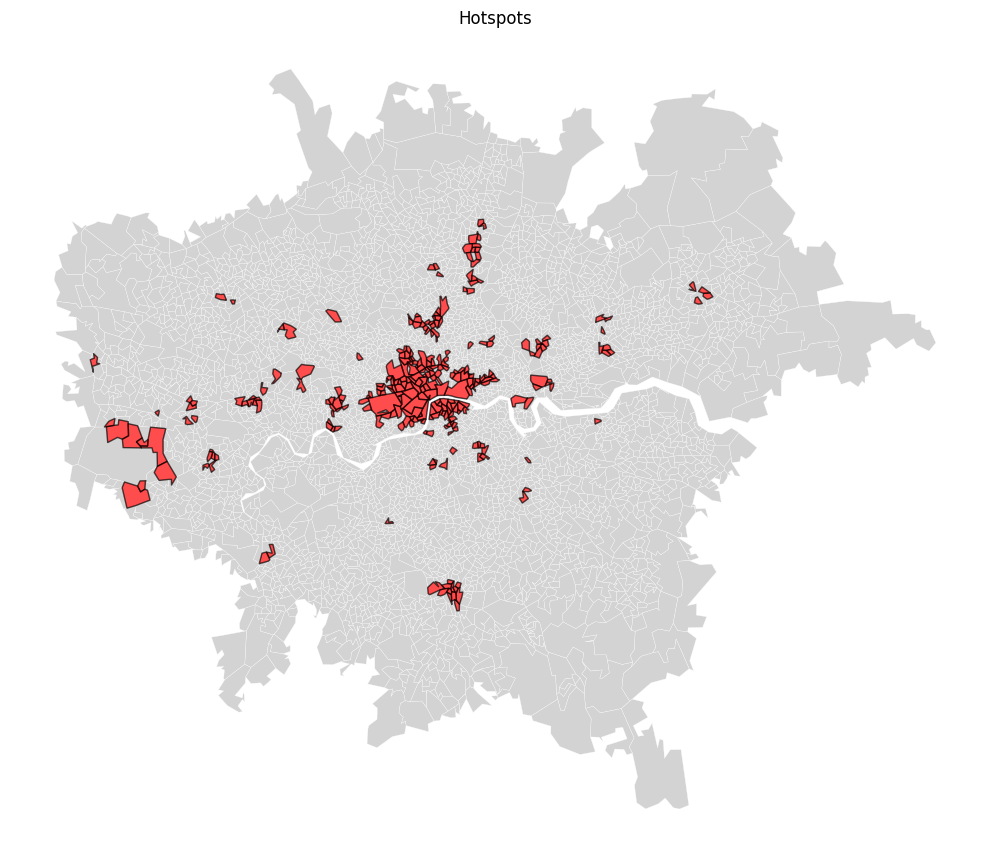

In [18]:
plot_hotspot(hotspots)

In [19]:
# Evaluation of the Local Moran's I
def evalution(gdf, hotspot_label="High-High (Hotspot)", value_col="crimes"):

    # Convert to British National Grid, to get square meters 
    gdf = gdf.to_crs(epsg=27700)

    # N = total number of cases in in the police force area
    N = gdf[value_col].sum()

    # n = number of cases in the hotspot region
    hotspot_gdf = gdf[gdf["cluster_classification"] == hotspot_label]
    n = hotspot_gdf[value_col].sum()

    # A = area of the police force (m^2)
    A = gdf.geometry.area.sum() 

    # a = the area of detected hotspots (m^2)
    a = hotspot_gdf.geometry.area.sum() 
    
    # Hit rate = n/N
    if N > 0:
        hit_rate = n/N
    else:
        hit_rate = 0

    # Area ratio = a/A
    if A > 0:
        area_ratio = a/A
    else:
        area_ratio = 0

    # PAI = Hit rate/Area ratio
    if area_ratio >0:
        PAI = hit_rate/area_ratio
    else: 
        PAI = 0

    # DCR = (n/a)/((N-n)/(A-a))
    if a == 0 or A == a or N == n:
        DCR = 0
    else:
        DCR = (n/a)/((N-n)/(A-a))

    return hit_rate, area_ratio, PAI, DCR

evalution(hotspots)

(np.float64(0.209552589995271),
 np.float64(0.03437336061171159),
 np.float64(6.096366088914589),
 np.float64(7.447444857696604))